# MIG Cement Demand Forecasting — Step 2: Data Profiling

**Scope of this notebook:** a structured, systematic characterization of the cleaned dataset —
shape, types, ranges, distributions, categorical breakdowns. This is deliberately *not* yet
hypothesis-driven analysis (that's the EDA notebook that follows). Think of profiling as
building a factual reference sheet of the dataset before we start asking "why" questions of it.


In [1]:
import pandas as pd

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_parquet("../outputs/cement_demand_clean.parquet")
print(df.shape)
df.head()


(32880, 21)


,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,...,region,behavior,year,month,day_of_week,is_weekend,capacity_utilization,over_capacity,overflow_tonnes,stockout_at_pour
0,2022-01-02,SITE_001,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,...,North,aggressive,2022,1,6,True,0.09,False,0.00,False
1,2022-01-04,SITE_001,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,...,North,aggressive,2022,1,1,False,0.07,False,0.00,False
2,2022-01-07,SITE_001,CEM_I,33.60,33.60,0.00,47.72,14.12,0.90,4.48,...,North,aggressive,2022,1,4,False,0.03,False,0.00,False
3,2022-01-08,SITE_001,CEM_I,42.12,34.28,14.12,20.16,0.00,1.95,25.92,...,North,aggressive,2022,1,5,True,0.00,False,0.00,True
4,2022-01-09,SITE_001,CEM_I,0.00,0.00,0.00,34.38,34.38,1.42,16.81,...,North,aggressive,2022,1,6,True,0.08,False,0.00,False


## 1. Structural overview

Row/column counts, dtypes, and memory footprint — the basics anyone reading this dataset for
the first time needs.


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 32880 entries, 0 to 32879
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      32880 non-null  datetime64[us]
 1   site_id                   32880 non-null  str           
 2   cement_type               32880 non-null  str           
 3   planned_pour_tonnes       32880 non-null  float64       
 4   consumed_tonnes           32880 non-null  float64       
 5   opening_inventory_tonnes  32880 non-null  float64       
 6   deliveries_tonnes         32880 non-null  float64       
 7   closing_inventory_tonnes  32880 non-null  float64       
 8   rain_mm                   32880 non-null  float64       
 9   avg_temp_c                32880 non-null  float64       
 10  silo_capacity             32880 non-null  int64         
 11  region                    32880 non-null  str           
 12  behavior                  328

## 2. Coverage: dates, sites, cement types

Before profiling values, confirm *what* the dataset actually covers — the date range, and how
many distinct sites, regions, and cement types are represented.


In [3]:
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
print("Unique dates:", df['date'].nunique())
print("Unique sites:", df['site_id'].nunique())
print("Unique cement types:", df['cement_type'].nunique(), list(df['cement_type'].unique()))
print("Unique regions:", df['region'].nunique(), list(df['region'].unique()))


Date range: 2022-01-01 to 2024-12-31
Unique dates: 1096
Unique sites: 30
Unique cement types: 3 ['CEM_I', 'CEM_II', 'CEM_III']
Unique regions: 4 ['North', 'South', 'East', 'West']


## 3. Categorical breakdowns

How the sites split across region and behaviour — these are the two categorical dimensions
we'll lean on heavily later, so it's worth knowing the group sizes up front (small groups
produce noisier averages, which matters when we interpret them).


In [4]:
print("Sites per region:")
print(df.drop_duplicates('site_id').groupby('region').size())
print()
print("Sites per behaviour:")
print(df.drop_duplicates('site_id').groupby('behavior').size())
print()
print("Rows per cement type:")
print(df['cement_type'].value_counts())


Sites per region:
region
East     12
North     3
South    11
West      4
dtype: int64

Sites per behaviour:
behavior
aggressive      14
chaotic          7
conservative     9
dtype: int64

Rows per cement type:
cement_type
CEM_II     11097
CEM_I      10913
CEM_III    10870
Name: count, dtype: int64


## 4. Descriptive statistics — numeric columns

Standard `describe()` output for every numeric column: min, max, quartiles, mean, std. This is
where you'd first spot an implausible value (e.g. a negative minimum, or a max far outside a
sane physical range) — we already ran targeted integrity checks in the cleaning notebook, but a
full descriptive pass is good practice as an independent second look.


In [5]:
numeric_cols = [
    "planned_pour_tonnes", "consumed_tonnes", "opening_inventory_tonnes",
    "deliveries_tonnes", "closing_inventory_tonnes", "rain_mm", "avg_temp_c",
    "silo_capacity", "capacity_utilization",
]
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
planned_pour_tonnes,"32,880.00",30.70,19.49,0.00,12.83,33.45,47.61,69.98
consumed_tonnes,"32,880.00",23.72,16.85,0.00,10.71,19.72,36.49,69.97
opening_inventory_tonnes,"32,880.00","3,066.68","5,586.03",0.00,1.28,50.71,"3,298.52","20,646.18"
deliveries_tonnes,"32,880.00",29.29,12.33,0.00,19.30,29.49,39.75,50.00
closing_inventory_tonnes,"32,880.00","3,072.25","5,593.02",0.00,1.27,50.66,"3,312.06","20,658.87"
rain_mm,"32,880.00",5.01,5.00,0.00,1.44,3.47,6.97,50.00
avg_temp_c,"32,880.00",10.09,8.52,-5.00,3.34,9.99,16.70,35.00
silo_capacity,"32,880.00",317.53,112.81,120.00,230.00,314.00,437.00,487.00
capacity_utilization,"32,880.00",11.74,25.02,0.00,0.00,0.17,10.52,172.16


**Reading it:** all tonnage columns have sane, non-negative ranges. `rain_mm` and
`avg_temp_c` fall within plausible UK-climate bounds. `capacity_utilization` has a very wide
range (its max is far above 1.0) — that's not a data error, it's the overstocking pattern we'll
dig into properly in the EDA notebook; profiling's job is just to flag that it's there.


In [6]:
print("capacity_utilization — min/median/max:")
print(df['capacity_utilization'].agg(['min', 'median', 'max']))


capacity_utilization — min/median/max:
min        0.00
median     0.17
max      172.16
Name: capacity_utilization, dtype: float64


## 5. Missing value map (recap)

Cleaning already confirmed zero nulls dataset-wide — reproduced here as a one-line profiling
check so this notebook stands on its own without requiring you to re-open the cleaning notebook.


In [7]:
df.isna().sum().sum()


np.int64(0)

## 6. Value distributions — quick histograms

A fast visual pass over the main numeric columns, purely descriptive (no interpretation yet —
that's EDA's job).


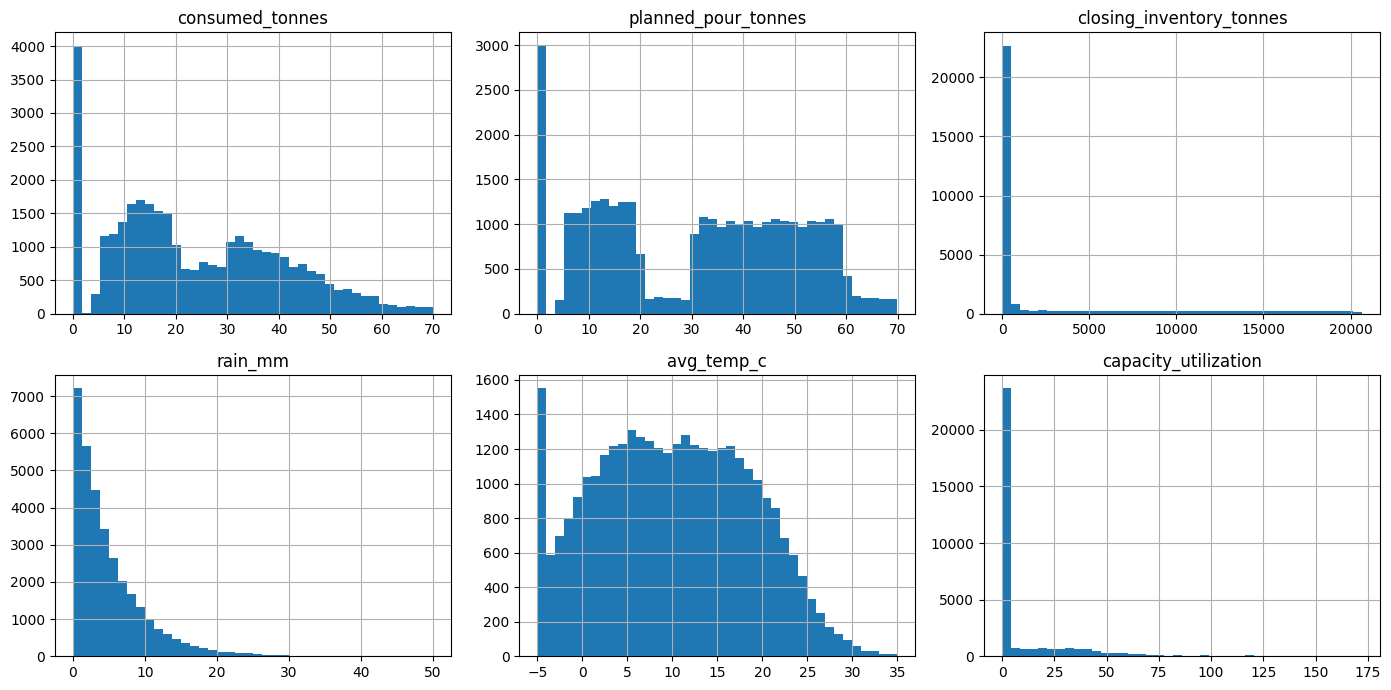

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
cols_to_plot = ["consumed_tonnes", "planned_pour_tonnes", "closing_inventory_tonnes",
                 "rain_mm", "avg_temp_c", "capacity_utilization"]
for ax, col in zip(axes.flat, cols_to_plot):
    df[col].hist(bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## Summary

| Aspect | Value |
|---|---|
| Rows × columns | 32,880 × 21 |
| Date range | 2022-01-01 to 2024-12-31 (3 full years) |
| Sites | 30, across 4 regions |
| Behaviour split | 14 aggressive / 9 conservative / 7 chaotic |
| Cement types | 3 (CEM_I, CEM_II, CEM_III), roughly evenly represented |
| Missing values | 0 |
| Notable range flag | `capacity_utilization` has a very wide range — investigated in EDA |

**Next notebook:** `eda/03_eda.ipynb` — trend, seasonality, weather effects, and the
behaviour-driven overstocking/stockout story this dataset turns out to tell.
